In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rishabhsnip/earth-observation-delhi-airshed")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed


In [3]:
!pip install geopandas rasterio shapely matplotlib seaborn scikit-learn tqdm opencv-python torch torchvision

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
import rasterio
from shapely.geometry import Point

from tqdm import tqdm
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [5]:
shapefile_path = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/delhi_ncr_region.geojson"

delhi_map = gpd.read_file(shapefile_path)

print(delhi_map.head())

                                            geometry
0  POLYGON ((76.85108 28.22115, 76.85219 28.22098...
1  POLYGON ((77.15903 29.29436, 77.15999 29.29427...
2  MULTIPOLYGON (((77.07565 27.27704, 77.07819 27...
3  POLYGON ((77.97073 28.71104, 77.97089 28.71096...
4  POLYGON ((77.2143 28.78524, 77.21521 28.78514,...


<Figure size 800x800 with 0 Axes>

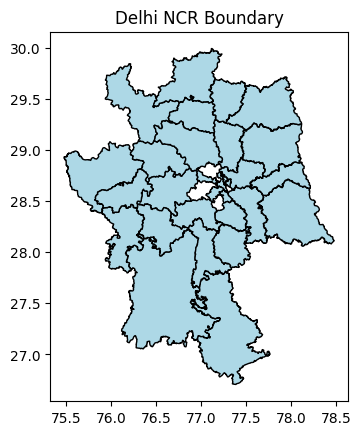

In [6]:
plt.figure(figsize=(8,8))
delhi_map.plot(edgecolor='black', facecolor='lightblue')
plt.title("Delhi NCR Boundary")
plt.show()

In [7]:
delhi_map = delhi_map.to_crs(epsg=4326)

In [8]:
delhi_polygon = delhi_map.geometry.iloc[0]

In [9]:
print(delhi_polygon)

POLYGON ((76.85107821913807 28.22115094553649, 76.85219386036222 28.220979626857076, 76.85293751067029 28.220713620360677, 76.85409897105284 28.22041144478684, 76.8549751577324 28.22012738681591, 76.8554285038766 28.220231153059004, 76.85616189715174 28.220515575295682, 76.85691574640875 28.220804408820147, 76.85760843175925 28.221196946157512, 76.85836742945047 28.221070760404665, 76.85935048819566 28.220863283529603, 76.85998731338735 28.220525053672187, 76.86074118210301 28.2201505741598, 76.86170898864157 28.21974014977621, 76.86250366196346 28.219392810657588, 76.86385350727724 28.21937487140911, 76.86489769968273 28.2191809618936, 76.86551401674015 28.219803626983442, 76.86685356968157 28.21988488509801, 76.86752592891564 28.219839787953102, 76.86814227384481 28.219731559875406, 76.86976207556837 28.219384185058573, 76.87185560867516 28.21886092177945, 76.87267057376054 28.218581199767666, 76.87350591516677 28.21826085569917, 76.87452707053993 28.217901071420908, 76.8748541622596

In [10]:
image_folder = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb"

image_files = os.listdir(image_folder)

print("Total images:", len(image_files))

Total images: 9216


In [11]:
import os

image_folder = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb"

image_files = os.listdir(image_folder)

print("Total images:", len(image_files))

print("\nFirst 10 filenames:\n")
for i in range(10):
    print(image_files[i])

Total images: 9216

First 10 filenames:

28.2266_77.5234.png
28.4266_77.2822.png
28.7591_77.2058.png
28.5355_77.3910.png
28.2943_77.0234.png
28.6942_77.1821.png
28.9266_77.4321.png
28.2442_77.1821.png
28.9178_77.0909.png
28.7591_76.8646.png


In [12]:
data = []

for img in image_files:

    name = img.replace(".png","")

    parts = name.split("_")

    lat = float(parts[0])
    lon = float(parts[1])

    data.append([img, lat, lon])

df = pd.DataFrame(data, columns=["image","lat","lon"])

df.head()

,image,lat,lon
0,28.2266_77.5234.png,28.2266,77.5234
1,28.4266_77.2822.png,28.4266,77.2822
2,28.7591_77.2058.png,28.7591,77.2058
3,28.5355_77.3910.png,28.5355,77.3910
4,28.2943_77.0234.png,28.2943,77.0234


In [13]:
geometry = [Point(xy) for xy in zip(df.lon, df.lat)]

gdf_images = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

In [14]:
filtered_images = gdf_images[gdf_images.within(delhi_polygon)]

In [15]:
delhi_map = delhi_map.to_crs(epsg=4326)

In [16]:
delhi_polygon = delhi_map.geometry.unary_union

/tmp/ipykernel_55/1517269082.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  delhi_polygon = delhi_map.geometry.unary_union


In [17]:
filtered_images = gdf_images[gdf_images.within(delhi_polygon)]

print("Total images:", len(gdf_images))
print("Images inside Delhi:", len(filtered_images))

Total images: 9216
Images inside Delhi: 8015


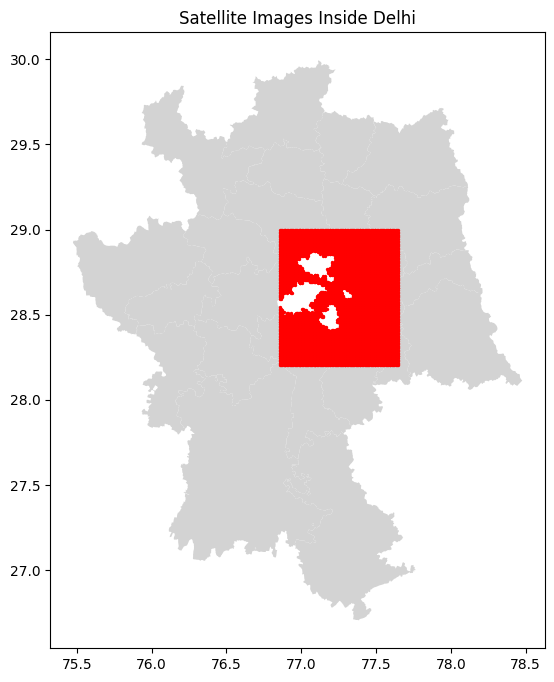

In [18]:
fig, ax = plt.subplots(figsize=(8,8))

delhi_map.plot(ax=ax, color='lightgray')

filtered_images.plot(ax=ax, color='red', markersize=2)

plt.title("Satellite Images Inside Delhi")
plt.show()

In [19]:
delhi_utm = delhi_map.to_crs(epsg=32643)

images_utm = filtered_images.to_crs(epsg=32643)

In [20]:
minx, miny, maxx, maxy = delhi_utm.total_bounds

print(minx, miny, maxx, maxy)

546142.9999656422 2956097.2599823284 841674.2309820709 3319945.580006641


In [21]:
grid_size = 60000

In [22]:
from shapely.geometry import box

grid_cells = []

x = minx

while x < maxx:
    
    y = miny
    
    while y < maxy:
        
        cell = box(x, y, x + grid_size, y + grid_size)
        
        grid_cells.append(cell)
        
        y += grid_size
        
    x += grid_size

In [23]:
grid = gpd.GeoDataFrame(grid_cells, columns=["geometry"], crs="EPSG:32643")

In [24]:
grid = gpd.overlay(grid, delhi_utm, how="intersection")

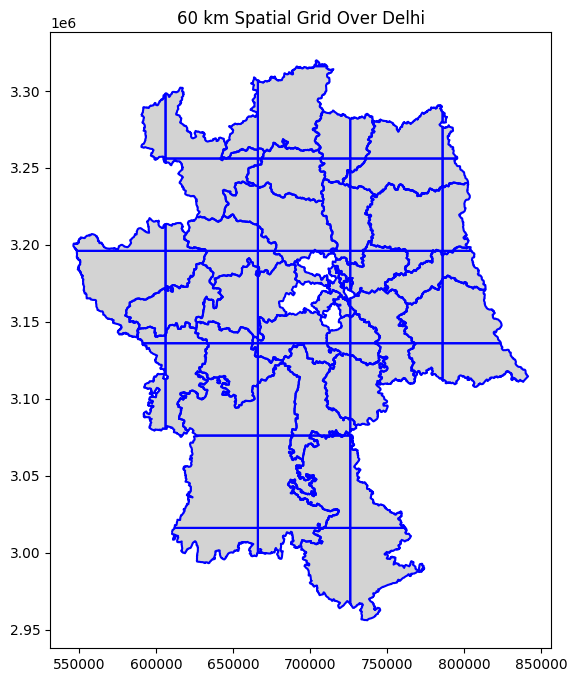

In [25]:
fig, ax = plt.subplots(figsize=(8,8))

delhi_utm.plot(ax=ax, color="lightgray")

grid.boundary.plot(ax=ax, color="blue")

plt.title("60 km Spatial Grid Over Delhi")

plt.show()

In [26]:
images_with_grid = gpd.sjoin(images_utm, grid, how="left", predicate="within")

In [27]:
images_with_grid.head()

,image,lat,lon,geometry,index_right
0,28.2266_77.5234.png,28.2266,77.5234,POINT (747630.664 3124884.569),71
1,28.4266_77.2822.png,28.4266,77.2822,POINT (723534.312 3146580.48),50
2,28.7591_77.2058.png,28.7591,77.2058,POINT (715369.797 3183291.685),42
3,28.5355_77.3910.png,28.5355,77.3910,POINT (733953.923 3158857.57),77
4,28.2943_77.0234.png,28.2943,77.0234,POINT (698425.542 3131465.389),37


In [28]:
grid_counts = images_with_grid.groupby("index_right").size()

print(grid_counts)

index_right
34       7
36     109
37     383
38     297
39      98
40       2
41      80
42     141
43       5
44     123
45     210
46      48
47     198
48      34
49     109
50     254
51     727
52     277
53       7
54     201
55     194
61     618
71     266
72     287
74     105
75     101
76      14
77    1092
78     931
79     123
81      11
82      20
83     335
84     237
85      74
87     297
dtype: int64


In [29]:
grid["image_count"] = grid_counts
grid["image_count"] = grid["image_count"].fillna(0)

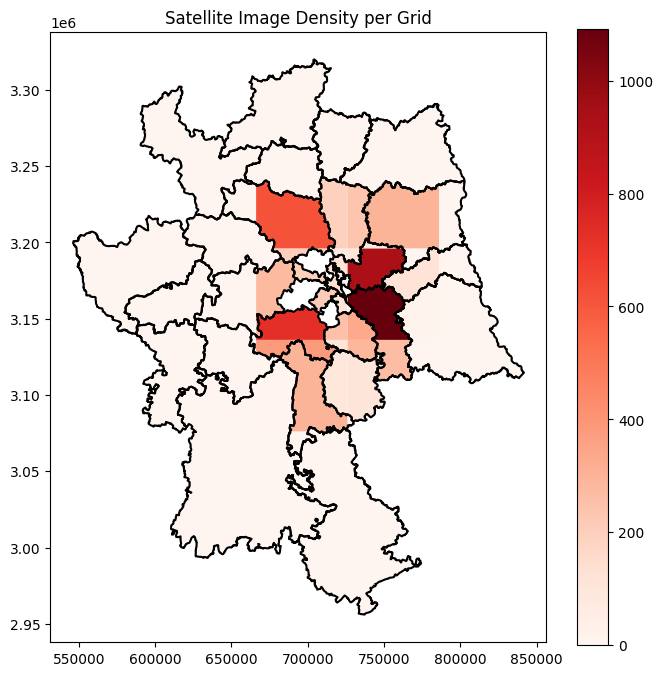

In [30]:
fig, ax = plt.subplots(figsize=(8,8))

grid.plot(column="image_count",
          cmap="Reds",
          legend=True,
          ax=ax)

delhi_utm.boundary.plot(ax=ax, color="black")

plt.title("Satellite Image Density per Grid")

plt.show()

In [31]:
import rasterio

raster_path = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/worldcover_bbox_delhi_ncr_2021.tif"

raster = rasterio.open(raster_path)

print(raster)

<open DatasetReader name='/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/worldcover_bbox_delhi_ncr_2021.tif' mode='r'>


In [32]:
print("CRS:", raster.crs)
print("Resolution:", raster.res)
print("Width:", raster.width)
print("Height:", raster.height)

CRS: EPSG:4326
Resolution: (8.333333333333333e-05, 8.333333333333333e-05)
Width: 9602
Height: 9600


In [33]:
images_raster_crs = filtered_images.to_crs(raster.crs)

In [34]:
labels = []

for point in images_raster_crs.geometry:
    
    x, y = point.x, point.y
    
    row, col = raster.index(x, y)
    
    value = raster.read(1)[row, col]
    
    labels.append(value)

images_raster_crs["landcover"] = labels

In [35]:
images_raster_crs.head()

,image,lat,lon,geometry,landcover
0,28.2266_77.5234.png,28.2266,77.5234,POINT (77.5234 28.2266),30
1,28.4266_77.2822.png,28.4266,77.2822,POINT (77.2822 28.4266),40
2,28.7591_77.2058.png,28.7591,77.2058,POINT (77.2058 28.7591),50
3,28.5355_77.3910.png,28.5355,77.3910,POINT (77.391 28.5355),50
4,28.2943_77.0234.png,28.2943,77.0234,POINT (77.0234 28.2943),40


In [36]:
images_raster_crs["landcover"].value_counts()

landcover
40    4494
50    1674
10     777
30     626
20     249
60     144
80      49
90       2
Name: count, dtype: int64

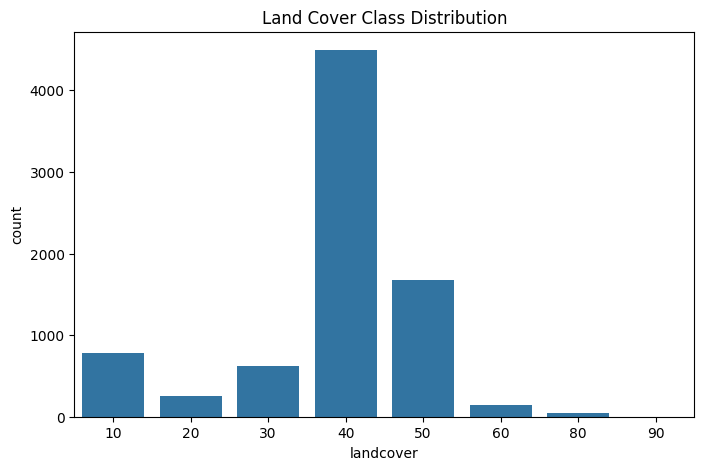

In [37]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x="landcover", data=images_raster_crs)

plt.title("Land Cover Class Distribution")

plt.show()

In [38]:
def map_landcover(x):

    if x == 50:
        return "built_up"

    elif x in [10,20,30]:
        return "vegetation"

    elif x == 40:
        return "cropland"

    elif x == 80:
        return "water"

    else:
        return "other"


images_raster_crs["class"] = images_raster_crs["landcover"].apply(map_landcover)

In [39]:
images_raster_crs["class"].value_counts()

class
cropland      4494
built_up      1674
vegetation    1652
other          146
water           49
Name: count, dtype: int64

In [40]:
images_raster_crs["class"].value_counts()

class
cropland      4494
built_up      1674
vegetation    1652
other          146
water           49
Name: count, dtype: int64

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

images_raster_crs["label"] = le.fit_transform(images_raster_crs["class"])

print(le.classes_)

['built_up' 'cropland' 'other' 'vegetation' 'water']


In [42]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    images_raster_crs,
    test_size=0.2,
    stratify=images_raster_crs["label"],
    random_state=42
)

print(len(train_df), len(test_df))

6412 1603


In [43]:
import torch
from torch.utils.data import Dataset
import cv2

image_folder = "/kaggle/input/delhi-airshed-sentinel-2-rgb-and-landco/rgb"

class SatelliteDataset(Dataset):

    def __init__(self, df):

        self.df = df.reset_index(drop=True)

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_path = os.path.join(image_folder, row["image"])

        img = cv2.imread(img_path)

        img = cv2.resize(img,(128,128))

        img = img / 255.0

        img = np.transpose(img,(2,0,1))

        label = row["label"]

        return torch.tensor(img,dtype=torch.float32), torch.tensor(label)

In [44]:
train_dataset = SatelliteDataset(train_df)
test_dataset = SatelliteDataset(test_df)

In [45]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=32)

In [46]:
import torch
import torch.nn as nn
import torchvision.models as models

In [47]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 242MB/s]


In [48]:
num_classes = len(le.classes_)

model.fc = nn.Linear(model.fc.in_features, num_classes)

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [50]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [51]:
import os

image_folder = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb"

# keep only images that actually exist
valid_rows = []

for _, row in images_raster_crs.iterrows():
    
    img_path = os.path.join(image_folder, row["image"])
    
    if os.path.exists(img_path):
        valid_rows.append(row)

clean_df = pd.DataFrame(valid_rows)

print("Original samples:", len(images_raster_crs))
print("Valid image samples:", len(clean_df))

Original samples: 8015
Valid image samples: 8015


In [52]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset

image_folder = "/kaggle/input/datasets/rishabhsnip/earth-observation-delhi-airshed/rgb"

class SatelliteDataset(Dataset):

    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_path = os.path.join(image_folder, row["image"])

        img = cv2.imread(img_path)

        # Handle missing images safely
        if img is None:
            img = np.zeros((128,128,3), dtype=np.float32)
        else:
            img = cv2.resize(img, (128,128))
            img = img.astype(np.float32)

        img = img / 255.0
        img = np.transpose(img, (2,0,1))

        label = int(row["label"])

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [53]:
train_dataset = SatelliteDataset(train_df)
test_dataset = SatelliteDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [54]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

Epoch 1/10, Loss: 166.4552
Epoch 2/10, Loss: 71.9082
Epoch 3/10, Loss: 22.2555
Epoch 4/10, Loss: 8.5359
Epoch 5/10, Loss: 7.6776
Epoch 6/10, Loss: 6.2601
Epoch 7/10, Loss: 7.3788
Epoch 8/10, Loss: 19.6536
Epoch 9/10, Loss: 19.0312
Epoch 10/10, Loss: 8.3513


In [55]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

In [56]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.7248908296943232
F1 Score: 0.7156378946241448


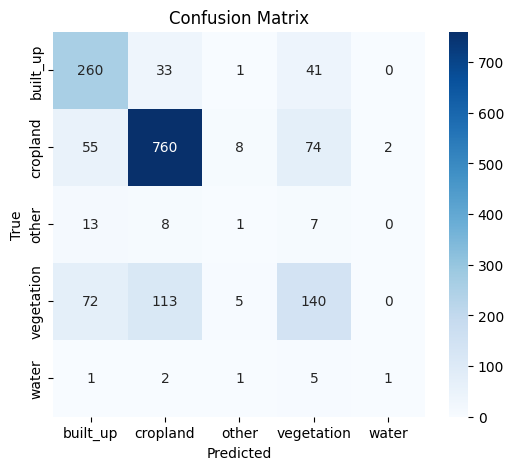

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

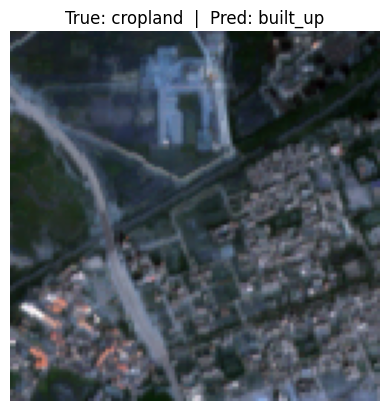

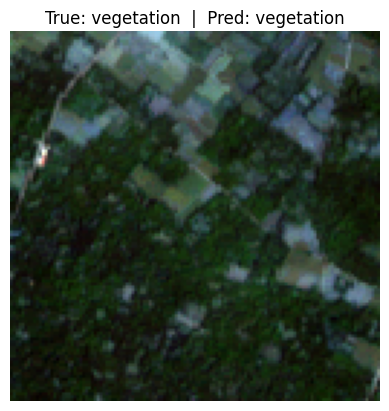

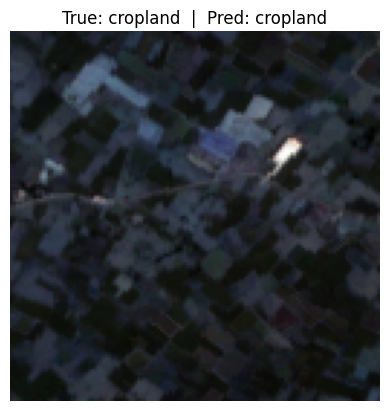

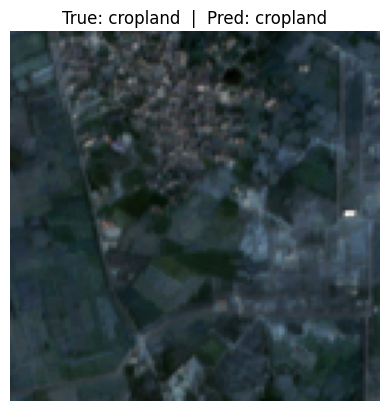

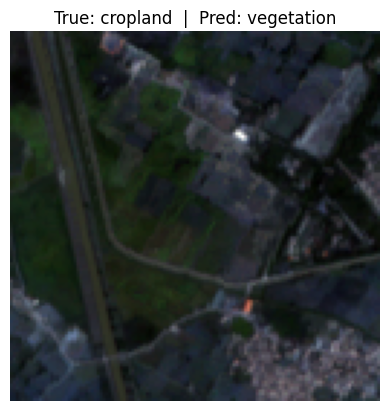

In [58]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    _, preds = torch.max(outputs,1)

for i in range(5):
    
    img = images[i].numpy().transpose(1,2,0)
    
    plt.imshow(img)
    plt.title(f"True: {le.classes_[labels[i]]}  |  Pred: {le.classes_[preds[i]]}")
    plt.axis("off")
    plt.show()